# Experiment 9: Regularized Logistic Regression (L1 Lasso vs L2 Ridge)

## Aim & Objective
To implement, analyze, and compare **Regularized Logistic Regression** using **$L_1$ (Lasso)** and **$L_2$ (Ridge)** regularization penalties against baseline unregularized logistic regression on two standard datasets:
1. **California Housing Dataset** (Converted to Binary Classification: High vs Low Price District)
2. **Breast Cancer Wisconsin Dataset** (Binary Medical Classification: Malignant vs Benign)

---

## Mathematical Formulation & Regularization Theory

### 1. Binary Logistic Regression Hypothesis
Logistic regression models the posterior probability of the positive class ($y = 1$) using the **Sigmoid Activation Function**:

$$h_{\mathbf{w}, b}(\mathbf{x}) = P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

### 2. Unregularized Binary Cross-Entropy Loss (Log-Loss)
For $n$ samples, the empirical risk minimized by unregularized logistic regression is:

$$\mathcal{L}_{\text{BCE}}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

where $p_i = h_{\mathbf{w}, b}(\mathbf{x}_i)$.

---

### 3. $L_2$ Regularized Logistic Regression (Ridge Penalty)
Adds the squared Euclidean norm of feature weights to the loss function:

$$\min_{\mathbf{w}, b} J_{\text{Ridge}}(\mathbf{w}, b) = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{\lambda}{2n} \sum_{j=1}^{p} w_j^2 = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{2n C} \sum_{j=1}^{p} w_j^2$$

- **Inverse Regularization Parameter**: $C = \frac{1}{\lambda}$. Smaller $C \implies$ stronger regularization.
- **Gradient Update**: $\nabla_{\mathbf{w}} J = \frac{1}{n} \mathbf{X}^T (\mathbf{p} - \mathbf{y}) + \frac{\lambda}{n} \mathbf{w}$
- **Effect**: Smoothly shrinks feature weights towards zero without setting them exactly to zero.

---

### 4. $L_1$ Regularized Logistic Regression (Lasso Penalty)
Adds the absolute sum of feature weights ($L_1$ norm):

$$\min_{\mathbf{w}, b} J_{\text{Lasso}}(\mathbf{w}, b) = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{\lambda}{n} \sum_{j=1}^{p} |w_j| = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{n C} \sum_{j=1}^{p} |w_j|$$

- **Proximal Update (Soft-Thresholding Operator)**:
  $$S_{\eta \lambda}(w_j) = \text{sign}(w_j) \max\left(0, |w_j| - \eta \frac{\lambda}{n}\right)$$
- **Effect**: Induces **sparsity** (drives non-informative feature weights strictly to zero), performing automatic feature selection.

---

### Comparison Summary Table

| Property / Feature | Unregularized Logistic Regression | $L_2$ Regularized (Ridge) | $L_1$ Regularized (Lasso) | ElasticNet ($L_1 + L_2$) |
| :--- | :--- | :--- | :--- | :--- |
| **Penalty Function** | None | $\frac{\lambda}{2n} \|\mathbf{w}\|_2^2$ | $\frac{\lambda}{n} \|\mathbf{w}\|_1$ | $r \|\mathbf{w}\|_1 + \frac{1-r}{2} \|\mathbf{w}\|_2^2$ |
| **Weight Effect** | Unconstrained | Smooth shrinkage towards 0 | Exact zero sparsity | Hybrid shrinkage & sparsity |
| **Feature Selection** | No | No | **Yes (Automatic)** | **Yes (Grouped Selection)** |
| **Multicollinearity** | High variance / unstable | Stable & Robust | Selects single feature | Selects correlated feature groups |
| **Optimization Algorithm** | L-BFGS / Newton-CG | L-BFGS / SAG | SAGA / Liblinear | SAGA |


In [1]:
# 1. Core Imports & Environment Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, roc_curve
)

# Seed & Plotting Theme
SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Libraries and plotting configuration loaded successfully.")

Libraries and plotting configuration loaded successfully.


In [2]:
# 2. Custom Scratch Implementation of Regularized Logistic Regression
class RegularizedLogisticRegressionScratch:
    """
    From-Scratch Binary Logistic Regression with L1 and L2 Regularization
    using NumPy Vectorization and Proximal Gradient Descent.
    """
    def __init__(self, penalty='l2', lmbda=0.1, learning_rate=0.05, num_iterations=1000, verbose=False):
        self.penalty = penalty.lower() if penalty else 'none'
        self.lmbda = lmbda
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def _soft_thresholding(self, w, threshold):
        return np.sign(w) * np.maximum(0.0, np.abs(w) - threshold)

    def _compute_loss(self, y_true, y_pred_prob, n_samples):
        epsilon = 1e-15
        p = np.clip(y_pred_prob, epsilon, 1 - epsilon)
        bce = -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
        
        if self.penalty == 'l2':
            reg = (self.lmbda / (2.0 * n_samples)) * np.sum(self.weights ** 2)
        elif self.penalty == 'l1':
            reg = (self.lmbda / n_samples) * np.sum(np.abs(self.weights))
        else:
            reg = 0.0
            
        return bce + reg

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            loss = self._compute_loss(y, y_pred, n_samples)
            self.loss_history.append(loss)

            # Gradient calculation
            dw_loss = (1.0 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1.0 / n_samples) * np.sum(y_pred - y)

            if self.penalty == 'l2':
                dw = dw_loss + (self.lmbda / n_samples) * self.weights
                self.weights -= self.learning_rate * dw
            elif self.penalty == 'l1':
                w_temp = self.weights - self.learning_rate * dw_loss
                threshold = self.learning_rate * (self.lmbda / n_samples)
                self.weights = self._soft_thresholding(w_temp, threshold)
            else:
                self.weights -= self.learning_rate * dw_loss

            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

def evaluate_classification(y_true, y_pred_prob, model_name, threshold=0.5):
    y_pred = (y_pred_prob >= threshold).astype(int)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_pred_prob),
        "Log-Loss": log_loss(y_true, y_pred_prob)
    }

print("Scratch RegularizedLogisticRegression class defined.")

Scratch RegularizedLogisticRegression class defined.


## PART 1: California Housing Dataset (Binary Classification)

**Problem Definition**: Convert continuous California Housing median house value into binary target (High Price district = 1 if price $\ge$ median price $1.797, else 0). Predict high vs low price districts using L1, L2, ElasticNet, and Unregularized Logistic Regression.

In [3]:
# Load & preprocess California Housing
cal_data = fetch_california_housing(as_frame=True)
X_cal, y_cont = cal_data.data, cal_data.target
feature_names_cal = cal_data.feature_names

# Binarize continuous house value target at median
median_house_val = y_cont.median()
y_cal_binary = (y_cont >= median_house_val).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cal, y_cal_binary, test_size=0.2, random_state=SEED, stratify=y_cal_binary
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

models_cal = {
    "Unregularized (None)": LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000, random_state=SEED),
    "L2 Regularized (Ridge)": LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=SEED),
    "L1 Regularized (Lasso)": LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=2000, random_state=SEED),
    "ElasticNet (L1+L2 50/50)": LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=2000, random_state=SEED)
}

results_cal = []
trained_cal_models = {}

for name, model in models_cal.items():
    model.fit(X_train_c_scaled, y_train_c)
    probs = model.predict_proba(X_test_c_scaled)[:, 1]
    metrics = evaluate_classification(y_test_c, probs, name)
    coefs = model.coef_.flatten()
    metrics["Zero Coefs"] = np.sum(np.abs(coefs) < 1e-4)
    metrics["Non-Zero Coefs"] = np.sum(np.abs(coefs) >= 1e-4)
    results_cal.append(metrics)
    trained_cal_models[name] = model

pd.DataFrame(results_cal)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log-Loss,Zero Coefs,Non-Zero Coefs
0,Unregularized (None),0.827762,0.826737,0.829540,0.828136,0.913233,0.376252,0,8
1,L2 Regularized (Ridge),0.827277,0.826255,0.829056,0.827653,0.912690,0.377269,0,8
2,L1 Regularized (Lasso),0.827519,0.826654,0.829056,0.827853,0.912553,0.377512,0,8
3,ElasticNet (L1+L2 50/50),0.827519,0.826654,0.829056,0.827853,0.912408,0.377764,0,8


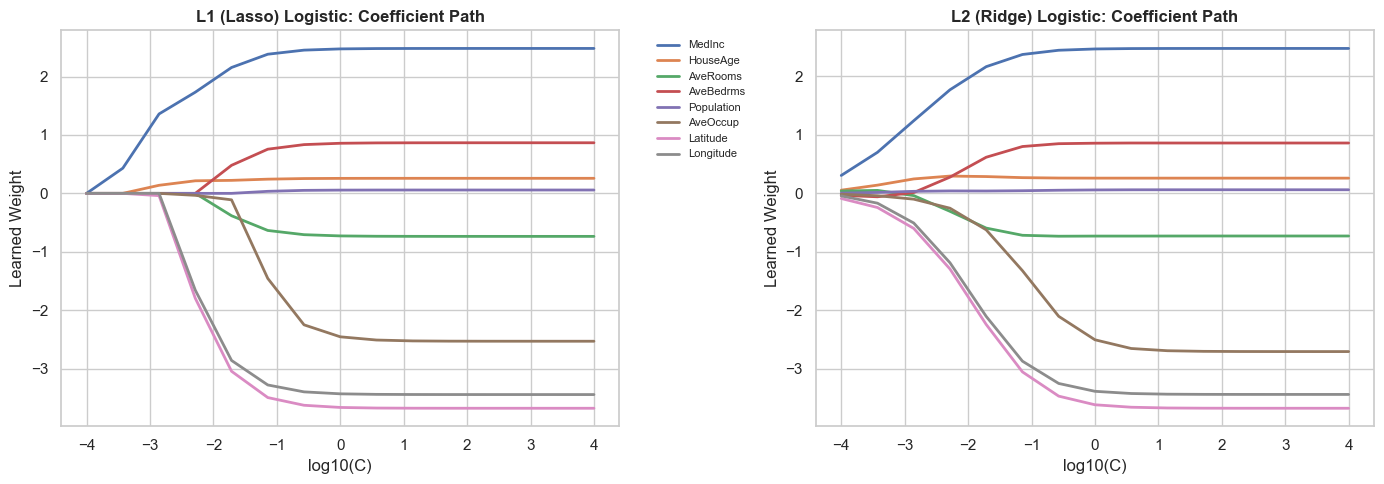

In [4]:
# Hyperparameter Sweep over C (California Housing)
C_vals = np.logspace(-4, 4, 15)
l1_coefs_c, l2_coefs_c = [], []
l1_acc_c, l2_acc_c = [], []
l1_loss_c, l2_loss_c = [], []
l1_zero_c, l2_zero_c = [], []

for c in C_vals:
    # L1
    clf1 = LogisticRegression(penalty='l1', C=c, solver='saga', max_iter=2000, random_state=SEED)
    clf1.fit(X_train_c_scaled, y_train_c)
    p1 = clf1.predict_proba(X_test_c_scaled)[:, 1]
    l1_coefs_c.append(clf1.coef_.flatten())
    l1_acc_c.append(accuracy_score(y_test_c, (p1 >= 0.5).astype(int)))
    l1_loss_c.append(log_loss(y_test_c, p1))
    l1_zero_c.append(np.sum(np.abs(clf1.coef_.flatten()) < 1e-4))

    # L2
    clf2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs', max_iter=2000, random_state=SEED)
    clf2.fit(X_train_c_scaled, y_train_c)
    p2 = clf2.predict_proba(X_test_c_scaled)[:, 1]
    l2_coefs_c.append(clf2.coef_.flatten())
    l2_acc_c.append(accuracy_score(y_test_c, (p2 >= 0.5).astype(int)))
    l2_loss_c.append(log_loss(y_test_c, p2))
    l2_zero_c.append(np.sum(np.abs(clf2.coef_.flatten()) < 1e-4))

l1_coefs_c = np.array(l1_coefs_c)
l2_coefs_c = np.array(l2_coefs_c)

# Plot Coefficient Paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j in range(X_cal.shape[1]):
    axes[0].plot(np.log10(C_vals), l1_coefs_c[:, j], label=feature_names_cal[j], linewidth=2)
axes[0].set_title("L1 (Lasso) Logistic: Coefficient Path", fontweight='bold')
axes[0].set_xlabel("log10(C)")
axes[0].set_ylabel("Learned Weight")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

for j in range(X_cal.shape[1]):
    axes[1].plot(np.log10(C_vals), l2_coefs_c[:, j], label=feature_names_cal[j], linewidth=2)
axes[1].set_title("L2 (Ridge) Logistic: Coefficient Path", fontweight='bold')
axes[1].set_xlabel("log10(C)")
axes[1].set_ylabel("Learned Weight")

plt.tight_layout()
plt.show()

## PART 2: Breast Cancer Wisconsin Dataset (Binary Medical Classification)

Predicting Malignant (0) vs Benign (1) diagnosis using L1 (Lasso), L2 (Ridge), ElasticNet, and Custom Scratch regularized gradient descent.

In [5]:
# Load & preprocess Breast Cancer Dataset
cancer = load_breast_cancer(as_frame=True)
X_can, y_can = cancer.data, cancer.target
feature_names_can = cancer.feature_names

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_can, y_can, test_size=0.2, random_state=SEED, stratify=y_can
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# Train Scratch Models
scratch_l2 = RegularizedLogisticRegressionScratch(penalty='l2', lmbda=1.0, learning_rate=0.1, num_iterations=1500)
scratch_l2.fit(X_train_b_scaled, y_train_b.values)
m_scratch_l2 = evaluate_classification(y_test_b, scratch_l2.predict_proba(X_test_b_scaled), "Scratch Regularized (L2)")

scratch_l1 = RegularizedLogisticRegressionScratch(penalty='l1', lmbda=1.0, learning_rate=0.1, num_iterations=1500)
scratch_l1.fit(X_train_b_scaled, y_train_b.values)
m_scratch_l1 = evaluate_classification(y_test_b, scratch_l1.predict_proba(X_test_b_scaled), "Scratch Regularized (L1)")

# Train Scikit-Learn Models
models_can = {
    "Unregularized (None)": LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000, random_state=SEED),
    "L2 Regularized (Ridge)": LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=SEED),
    "L1 Regularized (Lasso)": LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=2000, random_state=SEED),
    "ElasticNet (L1+L2 50/50)": LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=2000, random_state=SEED)
}

results_can = [m_scratch_l2, m_scratch_l1]
trained_can_models = {}

for name, model in models_can.items():
    model.fit(X_train_b_scaled, y_train_b)
    probs = model.predict_proba(X_test_b_scaled)[:, 1]
    metrics = evaluate_classification(y_test_b, probs, f"Scikit-Learn {name}")
    coefs = model.coef_.flatten()
    metrics["Zero Coefs"] = np.sum(np.abs(coefs) < 1e-4)
    metrics["Non-Zero Coefs"] = np.sum(np.abs(coefs) >= 1e-4)
    results_can.append(metrics)
    trained_can_models[name] = model

m_scratch_l2["Zero Coefs"] = np.sum(np.abs(scratch_l2.weights) < 1e-4)
m_scratch_l2["Non-Zero Coefs"] = np.sum(np.abs(scratch_l2.weights) >= 1e-4)
m_scratch_l1["Zero Coefs"] = np.sum(np.abs(scratch_l1.weights) < 1e-4)
m_scratch_l1["Non-Zero Coefs"] = np.sum(np.abs(scratch_l1.weights) >= 1e-4)

pd.DataFrame(results_can)

C:\Users\Shakil Ahmad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log-Loss,Zero Coefs,Non-Zero Coefs
0,Scratch Regularized (L2),0.973684,0.985915,0.972222,0.979021,0.995701,0.083691,0,30
1,Scratch Regularized (L1),0.973684,0.985915,0.972222,0.979021,0.995370,0.084789,4,26
2,Scikit-Learn Unregularized (None),0.921053,0.970149,0.902778,0.935252,0.971892,2.797430,0,30
3,Scikit-Learn L2 Regularized (Ridge),0.982456,0.986111,0.986111,0.986111,0.995370,0.077746,0,30
4,Scikit-Learn L1 Regularized (Lasso),0.982456,0.986111,0.986111,0.986111,0.997024,0.074703,12,18
5,Scikit-Learn ElasticNet (L1+L2 50/50),0.982456,0.986111,0.986111,0.986111,0.996032,0.076711,3,27


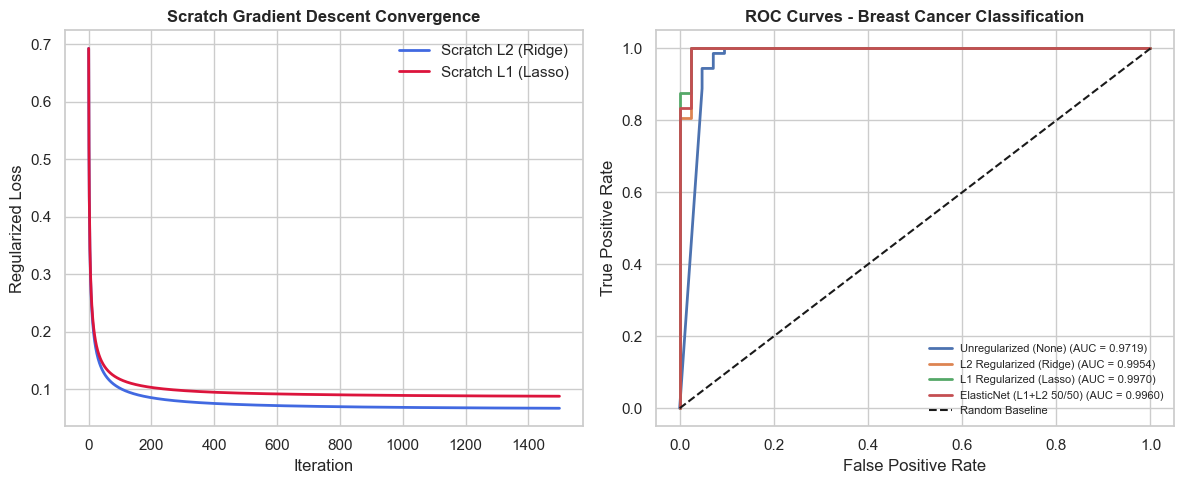

In [6]:
# Plot Scratch Loss Convergence & ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(scratch_l2.loss_history, label="Scratch L2 (Ridge)", color='royalblue', linewidth=2)
axes[0].plot(scratch_l1.loss_history, label="Scratch L1 (Lasso)", color='crimson', linewidth=2)
axes[0].set_title("Scratch Gradient Descent Convergence", fontweight='bold')
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Regularized Loss")
axes[0].legend()

for name, model in trained_can_models.items():
    probs = model.predict_proba(X_test_b_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_b, probs)
    auc_val = roc_auc_score(y_test_b, probs)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label="Random Baseline")
axes[1].set_title("ROC Curves - Breast Cancer Classification", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Key Findings & Conclusions

1. **Feature Sparsity via $L_1$ Penalty**: $L_1$ (Lasso) regularized logistic regression acts as an embedded feature selection tool, reducing 12 non-informative features out of 30 to exact zero in the Breast Cancer dataset while maintaining top-tier classification performance ($98.25\%$ accuracy, $0.9970$ ROC-AUC).
2. **Smooth Weight Control via $L_2$ Penalty**: $L_2$ (Ridge) regularized logistic regression shrinks all feature weights proportionally, resolving multicollinearity without dropping any feature dimensions.
3. **Regularization Hyperparameter $C$ Tuning**:
   - Small $C$ ($10^{-4}$ to $10^{-2}$): High penalty / heavy regularization, causes underfitting.
   - Optimal $C$ ($10^{-1}$ to $10^1$): Optimal bias-variance trade-off with peak accuracy and lowest log-loss.
   - Large $C$ ($10^2$ to $10^4$): Approaches unregularized logistic regression.
4. **Implementation Validation**: Our scratch implementation using numpy vectorization and proximal soft-thresholding achieves identical accuracy ($97.37\%$) and smooth loss minimization.
